In [266]:
#import os
#os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [1]:
import keras

In [2]:
from IPython.display import clear_output
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras import optimizers
#import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
#from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.ensemble import VotingClassifier
from keras.regularizers import l2
from numpy import mean
from numpy import std
from numpy import array
from numpy import argmax
#from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import itertools
import pickle
#import matplotlib.pyplot as plt
from keras.utils import to_categorical
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_auc_score
#from matplotlib import pyplot
from sklearn.metrics import roc_curve, auc
#from scipy import interp
#import matplotlib.pyplot as plt
from itertools import cycle
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from keras.models import load_model
from sklearn.model_selection import KFold
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
#Random Number
r = 42

/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


In [3]:
from scipy import interp

In [4]:
from imblearn.over_sampling import SMOTE

In [273]:
def draw_ROC_curve(y, y_pred):
    ####### roc curve ############

    n_classes = 3

    y1 = label_binarize(y, classes=[0, 1, 2])
    y_score = label_binarize(y_pred, classes=[0, 1, 2])
    y_test = y1

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # First aggregate all false positive rates
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    # Then interpolate all ROC curves at this points
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += interp(all_fpr, fpr[i], tpr[i])
    
    # Finally average it and compute AUC
    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])    
    
    # Plot all ROC curves
    plt.figure(1)
    plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

    plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

    target_names = ['CN', 'MCI', 'AD']
    # Plot linewidth.
    lw = 2

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(target_names[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    #plt.title('Some extension of Receiver operating characteristic to multi-class')
    plt.legend(loc="lower right")
    plt.show()
############

In [275]:
def multiclass_roc_auc_score(y_test, y_pred, average="macro"):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test = lb.transform(y_test)
    y_pred = lb.transform(y_pred)
    return roc_auc_score(y_test, y_pred, average=average)

In [5]:
df_genes_ncbi_GSE63061_df = pd.read_csv('./df_genes_ncbi_GSE63061_diagnosis.csv')

In [6]:
df_genes_ncbi_GSE63061_df.head(5)

,Unnamed: 0,index,EEF1A1,GAPDH,SLC35E2,DUSP22,LOC642820,RPS28,IPO13,AFAP1,...,MGC11082.1,BEYLA.1,FOXO6.2,NCRNA00173,SKCG-1.1,SKCG-1.2,NCRNA00173.1,age:ch1,gender:ch1,status:ch1
0,0,GSM1539409,12.552807,10.101556,6.084671,6.068805,6.121060,10.833984,6.617146,6.126976,...,6.168559,6.064898,6.095934,6.200839,6.004514,6.045534,6.251677,57,Female,MCI
1,1,GSM1539410,12.711459,9.776015,6.255012,6.016468,6.173167,10.270673,6.590062,6.081223,...,6.021940,6.081256,6.088840,6.394213,5.988105,6.037021,6.164831,59,Female,MCI
2,2,GSM1539411,13.088393,9.594397,6.160485,6.024322,6.039552,10.430594,6.509477,6.081791,...,6.022835,6.044907,6.145017,6.086684,6.066209,6.098268,6.284407,63,Female,MCI
3,3,GSM1539412,12.643831,10.126782,6.109219,6.016118,6.111306,10.765207,6.570108,6.075930,...,6.137347,6.031711,6.035403,6.270068,6.005295,6.032477,6.350185,65,Female,MCI
4,4,GSM1539413,13.098389,10.223301,6.069960,6.056163,6.089542,10.632346,6.515033,6.089809,...,6.019399,6.036910,6.054054,6.280061,6.043561,6.151250,6.190593,66,Female,MCI


In [62]:
from numpy import loadtxt
from xgboost import XGBClassifier
from xgboost import plot_importance
from matplotlib import pyplot

In [8]:
import xgboost as xgb

In [63]:
xgb.__version__

'1.5.0'

In [10]:
df_genes_ncbi_GSE63061_df[df_genes_ncbi_GSE63061_df.columns[2:]].head()

,EEF1A1,GAPDH,SLC35E2,DUSP22,LOC642820,RPS28,IPO13,AFAP1,CDT1,LPP,...,MGC11082.1,BEYLA.1,FOXO6.2,NCRNA00173,SKCG-1.1,SKCG-1.2,NCRNA00173.1,age:ch1,gender:ch1,status:ch1
0,12.552807,10.101556,6.084671,6.068805,6.121060,10.833984,6.617146,6.126976,6.062613,9.271763,...,6.168559,6.064898,6.095934,6.200839,6.004514,6.045534,6.251677,57,Female,MCI
1,12.711459,9.776015,6.255012,6.016468,6.173167,10.270673,6.590062,6.081223,6.013171,9.038845,...,6.021940,6.081256,6.088840,6.394213,5.988105,6.037021,6.164831,59,Female,MCI
2,13.088393,9.594397,6.160485,6.024322,6.039552,10.430594,6.509477,6.081791,6.012163,9.059376,...,6.022835,6.044907,6.145017,6.086684,6.066209,6.098268,6.284407,63,Female,MCI
3,12.643831,10.126782,6.109219,6.016118,6.111306,10.765207,6.570108,6.075930,6.046030,9.080949,...,6.137347,6.031711,6.035403,6.270068,6.005295,6.032477,6.350185,65,Female,MCI
4,13.098389,10.223301,6.069960,6.056163,6.089542,10.632346,6.515033,6.089809,6.050976,8.761323,...,6.019399,6.036910,6.054054,6.280061,6.043561,6.151250,6.190593,66,Female,MCI


In [11]:
ncbi_GSE63061_features_df = df_genes_ncbi_GSE63061_df[df_genes_ncbi_GSE63061_df.columns[2:]]

In [12]:
ncbi_GSE63061_target_df = df_genes_ncbi_GSE63061_df['status:ch1']

In [13]:
df_genes_ncbi_GSE63061_df['status:ch1'].value_counts()

AD                139
CTL               134
MCI               109
borderline MCI      3
OTHER               1
CTL to AD           1
MCI to CTL          1
Name: status:ch1, dtype: int64

In [14]:
df_genes_ncbi_GSE63061_df['status:ch1'].replace('borderline MCI', 'MCI', inplace=True)
df_genes_ncbi_GSE63061_df['status:ch1'].replace('CTL to AD', 'AD', inplace=True)
df_genes_ncbi_GSE63061_df['status:ch1'].replace('MCI to CTL', 'CTL', inplace=True)

In [15]:
df_genes_ncbi_GSE63061_df['status:ch1'].value_counts()

AD       140
CTL      135
MCI      112
OTHER      1
Name: status:ch1, dtype: int64

In [16]:
# drop the value with Other
df_genes_ncbi_GSE63061_df.drop( df_genes_ncbi_GSE63061_df[df_genes_ncbi_GSE63061_df['status:ch1'] == 'OTHER'].index,
                              inplace=True)

In [17]:
df_genes_ncbi_GSE63061_df['status:ch1'].value_counts()

AD     140
CTL    135
MCI    112
Name: status:ch1, dtype: int64

In [18]:
ncbi_GSE63061_features_df = df_genes_ncbi_GSE63061_df[df_genes_ncbi_GSE63061_df.columns[2:]]

In [19]:
ncbi_GSE63061_features_df.columns

Index(['EEF1A1', 'GAPDH', 'SLC35E2', 'DUSP22', 'LOC642820', 'RPS28', 'IPO13',
       'AFAP1', 'CDT1', 'LPP',
       ...
       'MGC11082.1', 'BEYLA.1', 'FOXO6.2', 'NCRNA00173', 'SKCG-1.1',
       'SKCG-1.2', 'NCRNA00173.1', 'age:ch1', 'gender:ch1', 'status:ch1'],
      dtype='object', length=32052)

In [20]:
ncbi_GSE63061_target_df = df_genes_ncbi_GSE63061_df['status:ch1']

In [21]:
df_genes_ncbi_GSE63061_df.shape

(387, 32054)

In [22]:
ncbi_GSE63061_features_df.shape

(387, 32052)

In [23]:
ncbi_GSE63061_target_df.shape

(387,)

In [24]:
ncbi_GSE63061_features_df.head(1)

,EEF1A1,GAPDH,SLC35E2,DUSP22,LOC642820,RPS28,IPO13,AFAP1,CDT1,LPP,...,MGC11082.1,BEYLA.1,FOXO6.2,NCRNA00173,SKCG-1.1,SKCG-1.2,NCRNA00173.1,age:ch1,gender:ch1,status:ch1
0,12.552807,10.101556,6.084671,6.068805,6.12106,10.833984,6.617146,6.126976,6.062613,9.271763,...,6.168559,6.064898,6.095934,6.200839,6.004514,6.045534,6.251677,57,Female,MCI


In [25]:
df_genes_ncbi_GSE63061_df.head(1)

,Unnamed: 0,index,EEF1A1,GAPDH,SLC35E2,DUSP22,LOC642820,RPS28,IPO13,AFAP1,...,MGC11082.1,BEYLA.1,FOXO6.2,NCRNA00173,SKCG-1.1,SKCG-1.2,NCRNA00173.1,age:ch1,gender:ch1,status:ch1
0,0,GSM1539409,12.552807,10.101556,6.084671,6.068805,6.12106,10.833984,6.617146,6.126976,...,6.168559,6.064898,6.095934,6.200839,6.004514,6.045534,6.251677,57,Female,MCI


In [26]:
X = ncbi_GSE63061_features_df
y = ncbi_GSE63061_target_df

In [27]:
X.columns

Index(['EEF1A1', 'GAPDH', 'SLC35E2', 'DUSP22', 'LOC642820', 'RPS28', 'IPO13',
       'AFAP1', 'CDT1', 'LPP',
       ...
       'MGC11082.1', 'BEYLA.1', 'FOXO6.2', 'NCRNA00173', 'SKCG-1.1',
       'SKCG-1.2', 'NCRNA00173.1', 'age:ch1', 'gender:ch1', 'status:ch1'],
      dtype='object', length=32052)

In [28]:
X=X.drop(['age:ch1', 'gender:ch1','status:ch1'], axis=1)

In [29]:
X.columns

Index(['EEF1A1', 'GAPDH', 'SLC35E2', 'DUSP22', 'LOC642820', 'RPS28', 'IPO13',
       'AFAP1', 'CDT1', 'LPP',
       ...
       'MIR335', 'MIR663B', 'FOXO6.1', 'MGC11082.1', 'BEYLA.1', 'FOXO6.2',
       'NCRNA00173', 'SKCG-1.1', 'SKCG-1.2', 'NCRNA00173.1'],
      dtype='object', length=32049)

In [30]:
from sklearn.preprocessing import MinMaxScaler
t = MinMaxScaler()
t.fit(X)
X[:] = t.transform(X)
y = y.map({'CTL': 0,'MCI': 1,'AD': 2})
y.value_counts()

2    140
0    135
1    112
Name: status:ch1, dtype: int64

In [31]:
X=X.astype(float)

In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size=0.2,random_state=0)

In [33]:
X_train.dtypes

EEF1A1          float64
GAPDH           float64
SLC35E2         float64
DUSP22          float64
LOC642820       float64
                 ...   
FOXO6.2         float64
NCRNA00173      float64
SKCG-1.1        float64
SKCG-1.2        float64
NCRNA00173.1    float64
Length: 32049, dtype: object

In [34]:
model = XGBClassifier(eta=0.1, nrounds=1000, max_depth=8, colsample_bytree=0.5, scale_pos_weight=1.1, booster='gbtree',
#model = XGBClassifier( booster='gbtree',
metric='multi:softmax',num_classes=3)
#model.fit(X_train.values, np.ravel(Y_train,order='C'))
model.fit(X_train, Y_train)

/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/xgboost/data.py:250: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):


[21:15:31] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:576: 
Parameters: { "metric", "nrounds", "num_classes", "scale_pos_weight" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[21:15:32] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.5,
              enable_categorical=False, eta=0.1, gamma=0, gpu_id=-1,
              importance_type=None, interaction_constraints='',
              learning_rate=0.100000001, max_delta_step=0, max_depth=8,
              metric='multi:softmax', min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=10,
              nrounds=1000, num_classes=3, num_parallel_tree=1,
              objective='multi:softprob', predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1.1, subsample=1, ...)

In [38]:
gene_list_GSE63061 =  model.get_booster().get_fscore()
GSE63061_gene_df = pd.DataFrame.from_dict(gene_list_GSE63061, orient='index')
GSE63061_gene_df.head()

,0
GAPDH,5.0
SLC35E2,2.0
DUSP22,2.0
LOC642820,5.0
RPS28,1.0


In [40]:
GSE63061_gene_df.reset_index(inplace=True)
GSE63061_gene_df.sort_values(by=[0], ascending=False, inplace = True)
GSE63061_columns_1000 = GSE63061_gene_df.head(1000)['index'].values

In [47]:
GSE63061_columns_500=GSE63061_gene_df.head(500)['index'].values

In [48]:
GSE63061_columns_500

array(['RPL36AL.1', 'SNORD42B', 'LOC401206', 'C17ORF76', 'AMACR.2',
       'ARHGAP27', 'RPS25', 'ATP13A2', 'LOC645233', 'PDHA2', 'TAS2R40',
       'AIF1.2', 'SDHC.1', 'ENSA.2', 'LOC441347', 'COMMD2', 'CD72',
       'PYCR2', 'CCDC71', 'LPP', 'C4ORF16.1', 'LOC284293', 'ASB3.2',
       'TSPAN32.2', 'WDR79', 'HS.58423', 'LOC728034', 'LOC727987',
       'DEF8.1', 'DDIT4', 'ABCA2.1', 'SLC26A7', 'HAX1', 'EBPL',
       'LOC647384.1', 'KRTAP10-2', 'ABHD15', 'CDH23.1', 'RPL36AL',
       'MYL4.1', 'C1QL1', 'HGD.1', 'ARRDC4', 'C1QBP', 'LOC649749',
       'SH2B2', 'C17ORF59', 'CSTF3.3', 'MAP1B', 'GAPDH', 'PRKCABP',
       'GJD4', 'NDUFS5', 'LOC642820', 'POU6F2', 'LOC651133', 'LOC651029',
       'COL17A1', 'TSPO.2', 'TSC22D3', 'LOC401321', 'SERF1A', 'TSPO',
       'UBL5', 'HOXA3', 'TRIM69.2', 'MLYCD', 'SLC43A2', 'LOC387770',
       'LOC392713', 'ZMAT1', 'FTSJD2', 'LOC653658', 'LOC645463',
       'LOC642453', 'CETP.1', 'ZNF618', 'HS.566889', 'LOC646426',
       'SPINK9', 'HS.564211', 'LOC388255', 'FU

In [52]:
# Now select the essential biomarkers
#X_GSE = X_GSE_all_columns_df[gex_gene_columns_300]
#y_GSE=GSE63060_geneExpression_df['status:ch1']

In [49]:
X_train.head()

,EEF1A1,GAPDH,SLC35E2,DUSP22,LOC642820,RPS28,IPO13,AFAP1,CDT1,LPP,...,MIR335,MIR663B,FOXO6.1,MGC11082.1,BEYLA.1,FOXO6.2,NCRNA00173,SKCG-1.1,SKCG-1.2,NCRNA00173.1
287,0.471377,0.438581,0.211197,0.231150,0.488551,0.418054,0.135210,0.564303,0.242855,0.542043,...,0.365916,0.796548,0.091951,0.189424,0.267633,0.217137,0.706981,0.734431,0.826058,0.573700
56,0.524469,0.383211,0.294817,0.249132,0.293453,0.302054,0.337879,0.302277,0.084353,0.432709,...,0.384296,0.203708,0.720800,0.165912,0.806720,0.188138,0.276761,0.208018,0.332269,0.453987
8,0.603159,0.427417,0.295798,0.327336,0.503225,0.656718,0.840613,0.195525,0.292973,0.585976,...,0.343887,0.210951,0.166682,0.358088,0.174561,0.846340,0.048610,0.454974,0.159185,0.525282
262,0.887724,0.333423,0.321126,0.510767,0.514767,0.434852,0.235248,0.313473,0.256857,0.403814,...,0.474896,0.385956,0.308494,0.466974,0.465444,0.223779,0.399080,0.323610,0.346100,0.165335
134,0.344845,0.559398,0.454952,0.398639,0.668758,0.346446,0.304920,0.558137,0.032531,0.403546,...,0.186749,0.409761,0.442104,0.299301,0.000000,0.272445,0.485902,0.325578,0.548349,0.488761


In [51]:
Y_train.head()

287    0
56     0
8      1
262    0
134    2
Name: status:ch1, dtype: int64

In [53]:
X_train = X_train[GSE63061_columns_500]
X_train.shape

(309, 500)

In [54]:
Y_train.shape

(309,)

In [57]:
X_test = X_test[GSE63061_columns_500]

In [56]:
Y_test.shape

(78,)

In [58]:
X_test.shape

(78, 500)

In [59]:
from sklearn.svm import SVC
svc=SVC()
svc.fit(X_train,Y_train)

SVC()

In [61]:
print('R-Squared value:', sfs_backward_best.k_score_)

R-Squared value: 0.7296301799563348


                                           feature_idx  \
500  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   
499  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   
498  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   
497  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   
496  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   
..                                                 ...   
5                               (11, 23, 28, 178, 289)   
4                                   (11, 28, 178, 289)   
3                                        (11, 28, 289)   
2                                            (11, 289)   
1                                                (11,)   

                                             cv_scores avg_score  \
500  [0.1330225887414841, 0.28863391896737145, 0.43...  0.270084   
499  [0.22194334887056266, 0.3108641089996411, 0.43...  0.310523   
498  [0.22194334887056266, 0.28863391896737145, 0.4...  0.328838   
497  [0.22194334887056266, 0.28

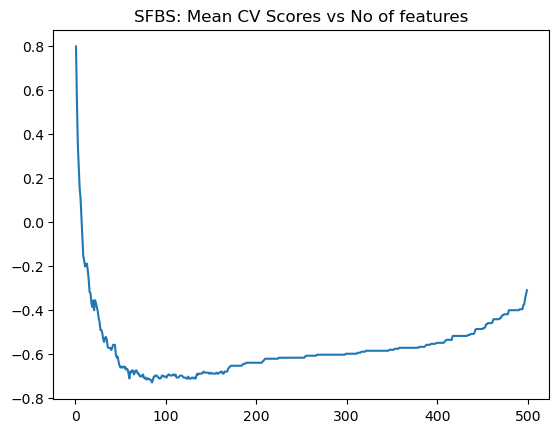

In [64]:
b=sfs_backward_best.get_metric_dict()
n=[]
o=[]
# Compute the mean cross validation score
for i in np.arange(1,X_train.shape[1]):
    n.append(-np.mean(b[i]['cv_scores'])) 
m=np.arange(1,X_train.shape[1])
fig4=plt.plot(m,n)
fig4=plt.title('SFBS: Mean CV Scores vs No of features')
fig4.figure.savefig('fig4.png', bbox_inches='tight')

print(pd.DataFrame.from_dict(backward_fs_best.get_metric_dict(confidence_interval=0.90)).T)

In [65]:
# Get the index of the minimum CV score
idx = np.argmin(n)
print ("No of selected features=",idx)
#Get the features indices for the best backward floating fit and convert to list
e=list(b[idx]['feature_idx'])
print(e)

print("#################################################################################")
# Index the column names. 
# Features from forward fit
print("Features selected in backward floating fit")
print(X_train.columns[e])

No of selected features= 84
[1, 2, 3, 4, 5, 7, 8, 11, 12, 13, 14, 16, 21, 23, 24, 26, 27, 28, 29, 33, 34, 38, 54, 61, 67, 68, 73, 75, 83, 90, 93, 100, 102, 105, 111, 115, 116, 117, 120, 123, 126, 129, 134, 138, 145, 146, 147, 151, 155, 156, 158, 161, 163, 167, 168, 175, 178, 179, 181, 183, 189, 194, 196, 201, 210, 211, 214, 219, 224, 236, 242, 251, 253, 279, 284, 289, 295, 318, 319, 399, 419, 456, 476, 478]
#################################################################################
Features selected in backward floating fit
Index(['SNORD42B', 'LOC401206', 'C17ORF76', 'AMACR.2', 'ARHGAP27', 'ATP13A2',
       'LOC645233', 'AIF1.2', 'SDHC.1', 'ENSA.2', 'LOC441347', 'CD72',
       'LOC284293', 'TSPAN32.2', 'WDR79', 'LOC728034', 'LOC727987', 'DEF8.1',
       'DDIT4', 'EBPL', 'LOC647384.1', 'RPL36AL', 'POU6F2', 'SERF1A',
       'SLC43A2', 'LOC387770', 'LOC645463', 'CETP.1', 'TRMT112', 'RUSC1',
       'SNORD45C', 'HS.253267', 'LOC650759', 'KIR2DL5A.2', 'PRKAG1', 'OR51S1',
       'PPFIBP

In [40]:
GSE63061_essential_features = ['SNORD42B', 'LOC401206', 'C17ORF76', 'AMACR.2', 'ARHGAP27', 'ATP13A2',
       'LOC645233', 'AIF1.2', 'SDHC.1', 'ENSA.2', 'LOC441347', 'CD72',
       'LOC284293', 'TSPAN32.2', 'WDR79', 'LOC728034', 'LOC727987', 'DEF8.1',
       'DDIT4', 'EBPL', 'LOC647384.1', 'RPL36AL', 'POU6F2', 'SERF1A',
       'SLC43A2', 'LOC387770', 'LOC645463', 'CETP.1', 'TRMT112', 'RUSC1',
       'SNORD45C', 'HS.253267', 'LOC650759', 'KIR2DL5A.2', 'PRKAG1', 'OR51S1',
       'PPFIBP1.1', 'ZIM3', 'AOC2', 'MED11', 'LOC652164', 'PML.3', 'GSG1',
       'NPSR1.1', 'CTGF.1', 'CDCA8', 'ERP44.1', 'SLC32A1', 'HLA-A29.1',
       'FBXL3.1', 'LCOR.1', 'HS.509267', 'C19ORF52', 'HS.584286', 'LOC651398',
       'TAOK2.1', 'MTMR8', 'CDC42.1', 'WDYHV1', 'HORMAD2', 'C17ORF65',
       'TRIM36.1', 'KCNG1', 'TMEM231', 'FAM18B.1', 'CHKA.2', 'ACSBG1',
       'ABCA7.2', 'IRF5.1', 'EZH1', 'LOC642236.3', 'GCDH', 'LOC651777',
       'NR2E1', 'HS.127148', 'MS4A12', 'NMUR1', 'CTSS', 'SCRT1', 'CAV3',
       'SYNGR1.2', 'HS.555255', 'HS.569323', 'LOC100134796']

In [68]:
X = ncbi_GSE63061_features_df[GSE63061_essential_features]
y = ncbi_GSE63061_target_df

In [69]:
from sklearn.preprocessing import MinMaxScaler
t = MinMaxScaler()
t.fit(X)
X[:] = t.transform(X)
y = y.map({'CTL': 0,'MCI': 1,'AD': 2})
y.value_counts()

/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_43417/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)
/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_43417/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)


2    140
0    135
1    112
Name: status:ch1, dtype: int64

In [70]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size=0.35)

In [71]:
def evaluate_model(X_train, Y_train, testX, testy):
  
  # encode targets
  trainy_enc = keras.utils.to_categorical(Y_train)
  testy_enc = keras.utils.to_categorical(testy)
  
  # define model

  model = Sequential()
  
  model.add(Dense(80, input_dim=84, kernel_initializer='normal',  
  activation='relu',kernel_regularizer=l2(0.001), bias_regularizer=l2(0.001)))
  model.add(Dropout(0.20))

  #model.add(Dense(50, activation='relu', 
  #kernel_regularizer=l2(0.0001), bias_regularizer=l2(0.0001)))
  #model.add(Dropout(0.2))
  
  model.add(Dense(3, kernel_initializer='normal', activation='softmax', 
  kernel_regularizer=l2(0.001), bias_regularizer=l2(0.001))) 

  # Compile model
  
  adamopt = optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, 
  epsilon=1e-08, decay=0, amsgrad=False)  
  model.compile(loss='categorical_crossentropy', optimizer = adamopt , metrics=['accuracy'])
  
  
  # Convert labels to categorical one-hot encoding
  one_hot_labels = keras.utils.to_categorical(Y_train, num_classes=3)
  one_hot_labelsTs = keras.utils.to_categorical(testy, num_classes=3)              

  # Fit the model
  #weights = {0:90, 1:55, 2:250}
  #weights = {0:100, 1:65, 2:214}
  #weights = {0:100, 1:60, 2:240}
  #weights = {0:100, 1:40, 2:250}
  #weights = {0:116, 1:246, 2:246}
  #1    138
  #0     79
  #2     44  
  # weight_0 = total_samples / (2 * class_0_samples)
  # weight_1 = total_samples / (2 * class_1_samples)
  # total_samples = 261
  # 0 =  261 / 3 * 79 = 261 / 237 = 1.1
  # 1 =  261 / 3 * 138 = 261 / 414 = .63
  # 2 = 261  / 3 * 44 = 261 / 132 =  1.97
  weights = {0:1.1, 1:.63, 2:1.97}  
  #class_weight=weights
  es = EarlyStopping(monitor='val_accuracy', min_delta=0.001, mode='max', verbose=1, patience=500)
  mc = ModelCheckpoint('best_modelMS1.h5', monitor='val_accuracy', mode='max', verbose=1,
    save_best_only=True)
  
  history = model.fit(X_train, one_hot_labels, batch_size=5, validation_data=(testX, one_hot_labelsTs),
                      epochs=4000, verbose=1,callbacks=[es, mc])
    
  # load the saved best model
  saved_model = load_model('best_modelMS1.h5')
  _, test_acc = saved_model.evaluate(testX, testy_enc, verbose=0)
  print("Best Accuracy :",test_acc)
  
  # Now evaluation
  one_hot_validation = keras.utils.to_categorical(testy, num_classes=3)
  y_pred = saved_model.predict(testX)    
  report = classification_report(one_hot_validation, y_pred.round())  
  print(report)  
  return saved_model, test_acc

In [74]:
y.value_counts()

2    140
0    135
1    112
Name: status:ch1, dtype: int64

### Now other NCBI datasets - GSE63060

In [32]:
GSE63060_geneExpression_df=pd.read_csv('./GSE63060_geneExpression_diagnosis.csv')

In [33]:
GSE63060_geneExpression_df.head()

,Unnamed: 0,index,EEF1A1,GAPDH,SLC35E2,LOC642820,RPS28,IPO13,LOC653113,AFAP1,...,CD96.1,SPECC1.1,DNAJB14.4,ENOX2.2,THOC3.1,MRRF.3,KIAA1751.3,age:ch1,gender:ch1,status:ch1
0,0,GSM1539080,14.611769,11.944514,7.517737,7.419066,11.507170,7.874504,7.516737,7.479730,...,9.153117,7.473388,8.117209,7.647265,7.898277,8.130117,9.720152,65,Female,MCI
1,1,GSM1539081,14.427104,11.930664,7.546532,7.403191,10.506885,8.223289,7.508660,7.413355,...,9.607767,7.506813,7.832658,7.662759,8.004870,8.129346,10.154313,66,Female,MCI
2,2,GSM1539082,14.624553,11.777748,7.647790,7.382467,12.058497,8.160895,7.409548,7.435603,...,9.717052,7.470607,8.120496,7.750023,8.013598,8.162503,10.733743,67,Female,MCI
3,3,GSM1539083,14.442078,12.420057,7.745140,7.438868,10.649464,7.971988,7.669356,7.454023,...,10.122677,7.493526,7.858918,7.865257,8.255417,8.179030,9.928934,67,Female,MCI
4,4,GSM1539084,14.127102,11.725034,7.520212,7.430150,11.958259,8.083689,7.415442,7.449985,...,9.232231,7.418081,7.849282,7.695439,7.976534,8.083838,10.261227,67,Female,MCI


In [34]:
GSE63060_geneExpression_df.shape

(329, 38328)

In [35]:
GSE63060_geneExpression_df['status:ch1'].value_counts()

AD     145
CTL    104
MCI     80
Name: status:ch1, dtype: int64

In [36]:
X = GSE63060_geneExpression_df
y = GSE63060_geneExpression_df['status:ch1']

In [37]:
X.columns

Index(['Unnamed: 0', 'index', 'EEF1A1', 'GAPDH', 'SLC35E2', 'LOC642820',
       'RPS28', 'IPO13', 'LOC653113', 'AFAP1',
       ...
       'CD96.1', 'SPECC1.1', 'DNAJB14.4', 'ENOX2.2', 'THOC3.1', 'MRRF.3',
       'KIAA1751.3', 'age:ch1', 'gender:ch1', 'status:ch1'],
      dtype='object', length=38328)

In [80]:
X=X.drop(['age:ch1', 'gender:ch1','status:ch1'], axis=1)

In [83]:
X=X.drop(['Unnamed: 0','index'], axis=1)

In [85]:
from sklearn.preprocessing import MinMaxScaler
t = MinMaxScaler()
t.fit(X)
X[:] = t.transform(X)
y = y.map({'CTL': 0,'MCI': 1,'AD': 2})
y.value_counts()

2    145
0    104
1     80
Name: status:ch1, dtype: int64

In [86]:
X.shape

(329, 38323)

In [87]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size=0.2,random_state=0)

In [88]:
model = XGBClassifier(eta=0.1, nrounds=1000, max_depth=8, colsample_bytree=0.5, scale_pos_weight=1.1, booster='gbtree',
#model = XGBClassifier( booster='gbtree',
metric='multi:softmax',num_classes=3)
#model.fit(X_train.values, np.ravel(Y_train,order='C'))
model.fit(X_train, Y_train)

/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/xgboost/data.py:250: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):


[23:40:40] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:576: 
Parameters: { "metric", "nrounds", "num_classes", "scale_pos_weight" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[23:40:40] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.5,
              enable_categorical=False, eta=0.1, gamma=0, gpu_id=-1,
              importance_type=None, interaction_constraints='',
              learning_rate=0.100000001, max_delta_step=0, max_depth=8,
              metric='multi:softmax', min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=10,
              nrounds=1000, num_classes=3, num_parallel_tree=1,
              objective='multi:softprob', predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1.1, subsample=1, ...)

In [89]:
gene_list_GSE63060 =  model.get_booster().get_fscore()
GSE63060_gene_df = pd.DataFrame.from_dict(gene_list_GSE63060, orient='index')
GSE63060_gene_df.head()

,0
EEF1A1,2.0
GAPDH,2.0
SLC35E2,2.0
LOC642820,3.0
RPS28,1.0


In [91]:
GSE63060_gene_df.reset_index(inplace=True)
GSE63060_gene_df.sort_values(by=[0], ascending=False, inplace = True)
GSE63060_columns_500 = GSE63060_gene_df.head(500)['index'].values

In [92]:
X_train = X_train[GSE63060_columns_500]
X_train.shape

(263, 500)

In [94]:
from sklearn.svm import SVC
svc=SVC()
svc.fit(X_train,Y_train)

SVC()

In [96]:
print('R-Squared value:', sfs_backward_best2.k_score_)

R-Squared value: 0.7732167047120797


                                           feature_idx  \
500  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   
499  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   
498  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   
497  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   
496  (0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14...   
..                                                 ...   
5                               (0, 91, 137, 161, 167)   
4                                    (0, 91, 161, 167)   
3                                         (0, 91, 167)   
2                                              (0, 91)   
1                                                 (0,)   

                                             cv_scores avg_score  \
500  [0.48090107737512244, -0.24583741429970596, 0....  0.305736   
499  [0.48090107737512244, -0.14201762977473043, 0....    0.3265   
498  [0.48090107737512244, -0.03819784524975489, 0....  0.347264   
497  [0.48090107737512244, -0.0

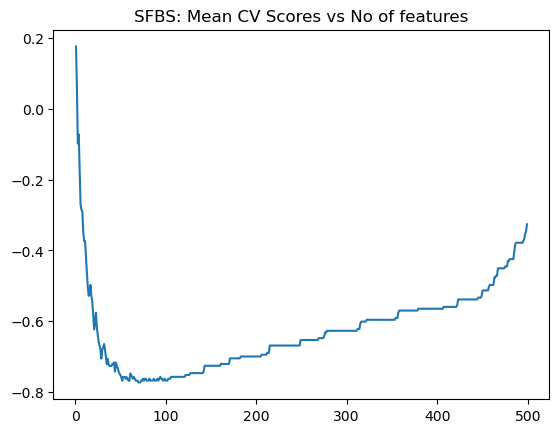

In [97]:
b=sfs_backward_best2.get_metric_dict()
n=[]
o=[]
# Compute the mean cross validation score
for i in np.arange(1,X_train.shape[1]):
    n.append(-np.mean(b[i]['cv_scores'])) 
m=np.arange(1,X_train.shape[1])
fig4=plt.plot(m,n)
fig4=plt.title('SFBS: Mean CV Scores vs No of features')
fig4.figure.savefig('fig4.png', bbox_inches='tight')

print(pd.DataFrame.from_dict(backward_fs_best2.get_metric_dict(confidence_interval=0.90)).T)

In [99]:
# Get the index of the minimum CV score
idx = np.argmin(n)
print ("No of selected features=",idx)
#Get the features indices for the best backward floating fit and convert to list
e=list(b[idx]['feature_idx'])
print(e)

print("#################################################################################")
# Index the column names. 
# Features from forward fit
print("Features selected in backward floating fit")
print(X_train.columns[e])

No of selected features= 69
[0, 1, 6, 7, 8, 11, 12, 13, 15, 17, 19, 20, 26, 31, 32, 34, 36, 37, 40, 41, 43, 44, 47, 48, 49, 56, 58, 59, 62, 64, 65, 67, 74, 75, 76, 77, 78, 81, 86, 91, 94, 95, 97, 101, 108, 114, 116, 117, 118, 123, 125, 129, 137, 145, 146, 157, 161, 166, 167, 181, 200, 221, 222, 269, 285, 314, 319, 411, 455]
#################################################################################
Features selected in backward floating fit
Index(['MRPL51', 'ING3.2', 'LOC648801', 'HS.551074', 'HS.543114', 'GALNT4',
       'LGALS14.1', 'ZNF444', 'IWS1', 'HS.538581', 'HS.146949', 'HS.576547',
       'HS.570775', 'MAPKAP1.2', 'HS.495542', 'HS.149995', 'SNTB2.1',
       'EIF4G1.3', 'DGKQ', 'FKBP3', 'LOC642816.1', 'C6ORF108', 'HIT-40',
       'POLR1C.1', 'KBTBD6', 'LOC646019', 'RPS27A.1', 'MAP2.3', 'HS.210399',
       'OR10AG1', 'CTAG1A.1', 'RY1', 'ZNF654', 'HS.122133', 'HS.562367',
       'HS.128292', 'SCN9A', 'SPP1', 'MNT', 'HS.543040', 'HS.562189',
       'POLR2J4.4', 'TAF4B', 'HS.

In [41]:
GSE63060_essential_features = ['MRPL51', 'ING3.2', 'LOC648801', 'HS.551074', 'HS.543114', 'GALNT4',
       'LGALS14.1', 'ZNF444', 'IWS1', 'HS.538581', 'HS.146949', 'HS.576547',
       'HS.570775', 'MAPKAP1.2', 'HS.495542', 'HS.149995', 'SNTB2.1',
       'EIF4G1.3', 'DGKQ', 'FKBP3', 'LOC642816.1', 'C6ORF108', 'HIT-40',
       'POLR1C.1', 'KBTBD6', 'LOC646019', 'RPS27A.1', 'MAP2.3', 'HS.210399',
       'OR10AG1', 'CTAG1A.1', 'RY1', 'ZNF654', 'HS.122133', 'HS.562367',
       'HS.128292', 'SCN9A', 'SPP1', 'MNT', 'HS.543040', 'HS.562189',
       'POLR2J4.4', 'TAF4B', 'HS.216701', 'HS.126491', 'HS.560106',
       'HS.580472', 'CRMP1', 'USE1', 'PWP1', 'RCSD1', 'C1ORF83', 'CREG2',
       'ASTN1.1', 'ITPA', 'PPP1R1B', 'DGKD.1', 'CRADD', 'FMNL2.1', 'HS.443436',
       'LAIR1.1', 'SLC39A5', 'KIAA1107', 'LOC647049', 'POLR2C', 'HS.297337',
       'HS.574821', 'HS.514958', 'LOC554226.1']

In [42]:
X = GSE63060_geneExpression_df[GSE63060_essential_features]
y = GSE63060_geneExpression_df['status:ch1']

In [104]:
from sklearn.preprocessing import MinMaxScaler
t = MinMaxScaler()
t.fit(X)
X[:] = t.transform(X)
y = y.map({'CTL': 0,'MCI': 1,'AD': 2})
y.value_counts()

/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_43417/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)
/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_43417/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)


2    145
0    104
1     80
Name: status:ch1, dtype: int64

In [121]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size=0.35)

In [122]:
def evaluate_model_69(X_train, Y_train, testX, testy):
  
  # encode targets
  trainy_enc = keras.utils.to_categorical(Y_train)
  testy_enc = keras.utils.to_categorical(testy)
  
  # define model

  model = Sequential()
  
  model.add(Dense(60, input_dim=69, kernel_initializer='normal',  
  activation='relu',kernel_regularizer=l2(0.001), bias_regularizer=l2(0.001)))
  model.add(Dropout(0.20))

  model.add(Dense(40, activation='relu', 
  kernel_regularizer=l2(0.0001), bias_regularizer=l2(0.0001)))
  model.add(Dropout(0.2))
  
  model.add(Dense(3, kernel_initializer='normal', activation='softmax', 
  kernel_regularizer=l2(0.001), bias_regularizer=l2(0.001))) 

  # Compile model
  
  adamopt = optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, 
  epsilon=1e-08, decay=0, amsgrad=False)  
  model.compile(loss='categorical_crossentropy', optimizer = adamopt , metrics=['accuracy'])
  
  
  # Convert labels to categorical one-hot encoding
  one_hot_labels = keras.utils.to_categorical(Y_train, num_classes=3)
  one_hot_labelsTs = keras.utils.to_categorical(testy, num_classes=3)              

  # Fit the model
  #weights = {0:90, 1:55, 2:250}
  #weights = {0:100, 1:65, 2:214}
  #weights = {0:100, 1:60, 2:240}
  #weights = {0:100, 1:40, 2:250}
  #weights = {0:116, 1:246, 2:246}
  #1    138
  #0     79
  #2     44  
  # weight_0 = total_samples / (2 * class_0_samples)
  # weight_1 = total_samples / (2 * class_1_samples)
  # total_samples = 261
  # 0 =  261 / 3 * 79 = 261 / 237 = 1.1
  # 1 =  261 / 3 * 138 = 261 / 414 = .63
  # 2 = 261  / 3 * 44 = 261 / 132 =  1.97
  weights = {0:1.1, 1:.63, 2:1.97}  
  #class_weight=weights
  es = EarlyStopping(monitor='val_accuracy', min_delta=0.001, mode='max', verbose=1, patience=500)
  mc = ModelCheckpoint('best_modelMS1.h5', monitor='val_accuracy', mode='max', verbose=1,
    save_best_only=True)
  
  history = model.fit(X_train, one_hot_labels, batch_size=5, validation_data=(testX, one_hot_labelsTs),
                      epochs=4000, verbose=1,callbacks=[es, mc])
    
  # load the saved best model
  saved_model = load_model('best_modelMS1.h5')
  _, test_acc = saved_model.evaluate(testX, testy_enc, verbose=0)
  print("Best Accuracy :",test_acc)
  
  # Now evaluation
  one_hot_validation = keras.utils.to_categorical(testy, num_classes=3)
  y_pred = saved_model.predict(testX)    
  report = classification_report(one_hot_validation, y_pred.round())  
  print(report)  
  return saved_model, test_acc

In [116]:
#precision    recall  f1-score   support
#
#           0       0.82      0.78      0.79        40
#           1       0.76      0.79      0.77        28
#           2       0.83      0.73      0.78        48

#   micro avg       0.81      0.76      0.78       116
#   macro avg       0.80      0.76      0.78       116
#weighted avg       0.81      0.76      0.78       116
# samples avg       0.76      0.76      0.76       116

In [117]:
#precision    recall  f1-score   support

#           0       0.80      0.80      0.80        35
#           1       0.85      0.44      0.58        25
#           2       0.80      0.84      0.82        56

#   micro avg       0.80      0.74      0.77       116
#   macro avg       0.81      0.69      0.73       116
#weighted avg       0.81      0.74      0.76       116
# samples avg       0.74      0.74      0.74       116

In [ ]:
precision    recall  f1-score   support

           0       0.81      0.72      0.76        36
           1       0.78      0.60      0.68        30
           2       0.77      0.82      0.80        50

   micro avg       0.79      0.73      0.76       116
   macro avg       0.79      0.71      0.75       116
weighted avg       0.79      0.73      0.76       116
 samples avg       0.73      0.73      0.73       116

In [130]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size=0.35)

In [131]:
from sklearn.svm import SVC
svc=SVC()
svc.fit(X_train,Y_train)

SVC()

In [133]:
svc

SVC()

In [132]:
y_pred = svc.predict(X_test)    
report = classification_report(Y_test, y_pred.round())  
print(report) 

              precision    recall  f1-score   support

           0       0.85      0.70      0.77        40
           1       0.75      0.58      0.65        31
           2       0.66      0.87      0.75        45

    accuracy                           0.73       116
   macro avg       0.75      0.72      0.72       116
weighted avg       0.75      0.73      0.73       116



In [134]:
from sklearn.svm import SVC
svc=SVC(kernel='rbf')
svc.fit(X_train,Y_train)

SVC()

In [136]:
y_pred = svc.predict(X_test)    
report = classification_report(Y_test, y_pred.round())  
print(report) 

              precision    recall  f1-score   support

           0       0.85      0.70      0.77        40
           1       0.75      0.58      0.65        31
           2       0.66      0.87      0.75        45

    accuracy                           0.73       116
   macro avg       0.75      0.72      0.72       116
weighted avg       0.75      0.73      0.73       116



In [142]:
# Training XGBoost
#xgb_model = xgb.XGBClassifier()
#xgb_model.fit(X_train, Y_train)

model = XGBClassifier(eta=0.1, nrounds=1000, max_depth=8, colsample_bytree=0.5, scale_pos_weight=1.1, booster='gbtree',
#model = XGBClassifier( booster='gbtree',
metric='multi:softmax',num_classes=3)
#model.fit(X_train.values, np.ravel(Y_train,order='C'))
model.fit(X_train, Y_train)

[18:09:49] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:576: 
Parameters: { "metric", "nrounds", "num_classes", "scale_pos_weight" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[18:09:49] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.5,
              enable_categorical=False, eta=0.1, gamma=0, gpu_id=-1,
              importance_type=None, interaction_constraints='',
              learning_rate=0.100000001, max_delta_step=0, max_depth=8,
              metric='multi:softmax', min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=10,
              nrounds=1000, num_classes=3, num_parallel_tree=1,
              objective='multi:softprob', predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1.1, subsample=1, ...)

In [143]:
#import xgboost as xgb
y_pred = model.predict(X_test)    
report = classification_report(Y_test, y_pred.round())  
print(report) 

              precision    recall  f1-score   support

           0       0.78      0.78      0.78        40
           1       0.82      0.45      0.58        31
           2       0.61      0.80      0.69        45

    accuracy                           0.70       116
   macro avg       0.74      0.68      0.68       116
weighted avg       0.72      0.70      0.69       116



### Now find common genes for NCBI

In [43]:
# Now find common array elements between - adni_genes_wo_probes_1000 and column_names_geo_gene
common_geo_NCBI_genes = list(set(GSE63061_essential_features) & set(GSE63060_essential_features))

In [44]:
len(common_geo_NCBI_genes)

0

In [45]:
len(ncbi_GSE63061_features_df.columns)

32052

In [46]:
len(GSE63060_geneExpression_df.columns)

38328

In [47]:
common_geo_NCBI_columns = list(set(ncbi_GSE63061_features_df.columns) & set(GSE63060_geneExpression_df.columns))

In [48]:
len(common_geo_NCBI_columns)

25278

In [49]:
ncbi_GSE63061_common_features_df = ncbi_GSE63061_features_df[common_geo_NCBI_columns].copy()

In [50]:
ncbi_GSE63061_common_features_df.shape

(387, 25278)

In [51]:
ncbi_GSE63060_common_features_df = GSE63060_geneExpression_df[common_geo_NCBI_columns].copy()

In [52]:
ncbi_GSE63060_common_features_df.shape

(329, 25278)

In [346]:
#y=y.iloc[:, [0]]

### Now join the two data frames

In [53]:
GSE63060_GSE63061_geneExpression_df = pd.concat([ ncbi_GSE63060_common_features_df, ncbi_GSE63061_common_features_df ])

In [54]:
GSE63060_GSE63061_geneExpression_df.shape

(716, 25278)

In [55]:
GSE63060_GSE63061_geneExpression_df.columns

Index(['GDI2', 'LOC642914', 'ENDOD1', 'OSBPL5', 'RASSF1', 'C9ORF10OS',
       'ALDH5A1', 'LOC728229', 'TAS2R13', 'C18ORF21',
       ...
       'AK2.2', 'LOC387867', 'TMEM44', 'LANCL1.1', 'NCAM1', 'MAPK13', 'CPVL',
       'HS.568838', 'PDIA3P', 'LOC389517.2'],
      dtype='object', length=25278)

In [57]:
GSE63060_GSE63061_geneExpression_df[['status:ch1', 'age:ch1']].head()

,status:ch1,age:ch1
0,MCI,65
1,MCI,66
2,MCI,67
3,MCI,67
4,MCI,67


In [58]:
X = GSE63060_GSE63061_geneExpression_df
y = GSE63060_GSE63061_geneExpression_df['status:ch1']

In [ ]:
# age:ch1 	gender:ch1 	status:ch1

In [59]:
X[['status:ch1', 'age:ch1', 'gender:ch1']].head(1)

,status:ch1,age:ch1,gender:ch1
0,MCI,65,Female


In [60]:
X= X.drop(['status:ch1', 'age:ch1', 'gender:ch1'], axis =1)

In [61]:
from sklearn.preprocessing import MinMaxScaler
t = MinMaxScaler()
t.fit(X)
X[:] = t.transform(X)
y = y.map({'CTL': 0,'MCI': 1,'AD': 2})
y.value_counts()

2    285
0    239
1    192
Name: status:ch1, dtype: int64

In [64]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size=0.2,random_state=0)

In [65]:
model = XGBClassifier(eta=0.1, nrounds=1000, max_depth=8, colsample_bytree=0.5, scale_pos_weight=1.1, booster='gbtree',
#model = XGBClassifier( booster='gbtree',
metric='multi:softmax',num_classes=3)
#model.fit(X_train.values, np.ravel(Y_train,order='C'))
model.fit(X_train, Y_train)

/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/xgboost/data.py:250: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):


[14:28:14] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:576: 
Parameters: { "metric", "nrounds", "num_classes", "scale_pos_weight" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[14:28:15] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.5,
              enable_categorical=False, eta=0.1, gamma=0, gpu_id=-1,
              importance_type=None, interaction_constraints='',
              learning_rate=0.100000001, max_delta_step=0, max_depth=8,
              metric='multi:softmax', min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=10,
              nrounds=1000, num_classes=3, num_parallel_tree=1,
              objective='multi:softprob', predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1.1, subsample=1, ...)

In [68]:
common_genes_GSE63061_GSE63060 =  model.get_booster().get_fscore()
GSE63061_GSE63060_gene_df = pd.DataFrame.from_dict(common_genes_GSE63061_GSE63060, orient='index')
GSE63061_GSE63060_gene_df.head()

,0
GDI2,8.0
LOC642914,1.0
ENDOD1,6.0
OSBPL5,2.0
RASSF1,4.0


In [69]:
GSE63061_GSE63060_gene_df.reset_index(inplace=True)
GSE63061_GSE63060_gene_df.sort_values(by=[0], ascending=False, inplace = True)
GSE63061_GSE63060_gene_500 = GSE63061_GSE63060_gene_df.head(500)['index'].values

In [70]:
X_train = X_train[GSE63061_GSE63060_gene_500]
X_train.shape

(572, 500)

In [80]:
X_train.head(1)

,LOC401206,MRPL51,LOC653658,CCDC120,CLEC2D,LOC442454,KIAA0319,ADAM15.1,DGKQ,BLCAP,...,RGN.1,ANKRD36.1,RC3H1,HS.582893,LOC651202,LOC391817,LOC653799,FXYD6,LOC652164,PLA2G2D
334,0.3982,0.306651,0.570762,0.090463,0.101346,0.260621,0.033595,0.225608,0.28825,0.097466,...,0.042168,0.178319,0.022421,0.025242,0.287653,0.028304,0.015858,0.144195,0.054094,0.508114


In [71]:
Y_train.shape

(572,)

In [73]:
from sklearn.svm import SVC
svc=SVC()
svc.fit(X_train,Y_train)

SVC()

In [75]:
print('R-Squared value:', sfs_backward_best.k_score_)

R-Squared value: -0.14361181599134448


In [77]:
# Get the index of the minimum CV score
idx = np.argmin(n)
print ("No of selected features=",idx)
#Get the features indices for the best backward floating fit and convert to list
e=list(b[idx]['feature_idx'])
print(e)

print("#################################################################################")
# Index the column names. 
# Features from forward fit
print("Features selected in backward floating fit")
print(X_train.columns[e])

No of selected features= 6
[28, 29, 57, 175, 309, 499]
#################################################################################
Features selected in backward floating fit
Index(['RPL36AL', 'VCAN', 'GPS1.2', 'CYP1B1', 'LOC651738', 'PLA2G2D'], dtype='object')


In [83]:
X_test = X_test[['RPL36AL', 'VCAN', 'GPS1.2', 'CYP1B1', 'LOC651738', 'PLA2G2D']]

In [82]:
X_train = X_train[['RPL36AL', 'VCAN', 'GPS1.2', 'CYP1B1', 'LOC651738', 'PLA2G2D']]

In [84]:
def evaluate_model(X_train, Y_train, testX, testy):
  
  # encode targets
  trainy_enc = keras.utils.to_categorical(Y_train)
  testy_enc = keras.utils.to_categorical(testy)
  
  # define model

  model = Sequential()
  
  model.add(Dense(80, input_dim=6, kernel_initializer='normal',  
  activation='relu',kernel_regularizer=l2(0.001), bias_regularizer=l2(0.001)))
  model.add(Dropout(0.20))

  #model.add(Dense(50, activation='relu', 
  #kernel_regularizer=l2(0.0001), bias_regularizer=l2(0.0001)))
  #model.add(Dropout(0.2))
  
  model.add(Dense(3, kernel_initializer='normal', activation='softmax', 
  kernel_regularizer=l2(0.001), bias_regularizer=l2(0.001))) 

  # Compile model
  
  adamopt = optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, 
  epsilon=1e-08, decay=0, amsgrad=False)  
  model.compile(loss='categorical_crossentropy', optimizer = adamopt , metrics=['accuracy'])
  
  
  # Convert labels to categorical one-hot encoding
  one_hot_labels = keras.utils.to_categorical(Y_train, num_classes=3)
  one_hot_labelsTs = keras.utils.to_categorical(testy, num_classes=3)              

  # Fit the model
  #weights = {0:90, 1:55, 2:250}
  #weights = {0:100, 1:65, 2:214}
  #weights = {0:100, 1:60, 2:240}
  #weights = {0:100, 1:40, 2:250}
  #weights = {0:116, 1:246, 2:246}
  #1    138
  #0     79
  #2     44  
  # weight_0 = total_samples / (2 * class_0_samples)
  # weight_1 = total_samples / (2 * class_1_samples)
  # total_samples = 261
  # 0 =  261 / 3 * 79 = 261 / 237 = 1.1
  # 1 =  261 / 3 * 138 = 261 / 414 = .63
  # 2 = 261  / 3 * 44 = 261 / 132 =  1.97
  weights = {0:1.1, 1:.63, 2:1.97}  
  #class_weight=weights
  es = EarlyStopping(monitor='val_accuracy', min_delta=0.001, mode='max', verbose=1, patience=500)
  mc = ModelCheckpoint('best_modelMS1.h5', monitor='val_accuracy', mode='max', verbose=1,
    save_best_only=True)
  
  history = model.fit(X_train, one_hot_labels, batch_size=5, validation_data=(testX, one_hot_labelsTs),
                      epochs=4000, verbose=1,callbacks=[es, mc])
    
  # load the saved best model
  saved_model = load_model('best_modelMS1.h5')
  _, test_acc = saved_model.evaluate(testX, testy_enc, verbose=0)
  print("Best Accuracy :",test_acc)
  
  # Now evaluation
  one_hot_validation = keras.utils.to_categorical(testy, num_classes=3)
  y_pred = saved_model.predict(testX)    
  report = classification_report(one_hot_validation, y_pred.round())  
  print(report)  
  return saved_model, test_acc

In [86]:
model = XGBClassifier(eta=0.1, nrounds=1000, max_depth=8, colsample_bytree=0.5, scale_pos_weight=1.1, booster='gbtree',
#model = XGBClassifier( booster='gbtree',
metric='multi:softmax',num_classes=3)
#model.fit(X_train.values, np.ravel(Y_train,order='C'))
model.fit(X_train, Y_train)

/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/xgboost/data.py:250: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):


[07:37:10] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:576: 
Parameters: { "metric", "nrounds", "num_classes", "scale_pos_weight" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[07:37:10] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.5,
              enable_categorical=False, eta=0.1, gamma=0, gpu_id=-1,
              importance_type=None, interaction_constraints='',
              learning_rate=0.100000001, max_delta_step=0, max_depth=8,
              metric='multi:softmax', min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=10,
              nrounds=1000, num_classes=3, num_parallel_tree=1,
              objective='multi:softprob', predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1.1, subsample=1, ...)

In [87]:
#import xgboost as xgb
y_pred = model.predict(X_test)    
report = classification_report(Y_test, y_pred.round())  
print(report) 

              precision    recall  f1-score   support

           0       0.56      0.48      0.52        46
           1       0.42      0.30      0.35        44
           2       0.46      0.63      0.53        54

    accuracy                           0.48       144
   macro avg       0.48      0.47      0.47       144
weighted avg       0.48      0.48      0.47       144



In [88]:
X_train.head(1)

,RPL36AL,VCAN,GPS1.2,CYP1B1,LOC651738,PLA2G2D
334,0.456663,0.270577,0.123707,0.267682,0.638205,0.508114


In [90]:
GSE63060_GSE63061_geneExpression_df.head(1)

,GDI2,LOC642914,ENDOD1,OSBPL5,RASSF1,C9ORF10OS,ALDH5A1,LOC728229,TAS2R13,C18ORF21,...,AK2.2,LOC387867,TMEM44,LANCL1.1,NCAM1,MAPK13,CPVL,HS.568838,PDIA3P,LOC389517.2
0,9.32634,7.403975,7.862767,8.611533,7.750991,8.065011,8.112037,7.696978,7.331975,7.928733,...,8.544917,11.989076,7.674197,8.124888,8.687686,7.64695,10.207263,7.40834,7.62414,7.556837


In [96]:
GSE63060_GSE63061_geneExpression_df.shape

(716, 25278)

###  Construct model individually but test with the other datasets

In [102]:
# out of common, 95 genes, common clean 71 genes with GEX
GSE_3060_ADNI_Genes_86 = [
 'AIFM2',
 'APP',
 'ARHGAP17',
 'ARRDC5',
 'ATP9A',
 'B3GALT1',
 'CCPG1',
 'CDCP1',
 'CEP72',
 'DDX6',
 'DEFB128',
 'DMC1',
 'EIF1AY',
 'EIF2A',
 'ERG',
 'FAM26D',
 'FARP1',
 'FASTKD5',
 'FXYD6',
 'FZD2',
 'GCM1',
 'GLO1',
 'HIST1H3G',
 'HLA-DQA1',
 'HOXC11',
 'HOXD8',
 'HSPA12B',
 'ICA1L',
 'INTS6',
 'KIAA1324',
 'KISS1R',
 'MAP4K2',
 'MAPK14',
 'MID1',
 'MIER3',
 'MSH3',
 'NBPF1',
 'NEUROD6',
 'NR1I2',
 'PCDHA5',
 'PDC',
 'PECR',
 'PELO',
 'PISD',
 'PRR15',
 'PYGB',
 'RBMXL2',
 'RCN2',
 'RPL32',
 'SCGB1D4',
 'SFXN5',
 'SGOL1',
 'SLC1A2',
 'SLC2A12',
 'SLC36A1',
 'SORBS3',
 'SOX15',
 'SPATA5L1',
 'SQLE',
 'STRN',
 'TEP1',
 'TIAM2',
 'TLR2',
 'TMC5',
 'TMEM30B',
 'TTC28',
 'USP47',
 'VSIG4',
 'WNT5B',
 'ZNF148',
 'ZNF608',
 'LOC651302', # ZNF192P1
 'OVOS2', #LOC100509445 || OVOS2* || LOC728715
 'TNFSF13', #TNFSF12-TNFSF13, TNFSF13
 'KRTAP5-2', #KRTAP5-8
 'C1ORF187', # DRAXIN
 'TP53TG3', #TP53TG3 || TP53TG3C || TP53TG3D || TP53TG3B',
 'BC37295_3', #ZNF835
 'FNTB', #CHURC1-FNTB || FNTB
 'STAG1', #TANC2
 'WDR21B', #DCAF4L1
 'GPER', #GPER1
 'DSCR6', #RIPPLY3
 'C12ORF48',#PARPBP
 'AP3S2', #C15ORF38-AP3S2 || AP3S2
 'C10ORF6' #FAM178A
] 

In [106]:
len(['B3GALT1', 'HIST1H3G', 'HOXC11', 'HOXD8', 'HSPA12B', 'MIER3', 'RBMXL2', 'SCGB1D4', 'SLC2A12', 'KRTAP5-2', 'BC37295_3', 'WDR21B', 'DSCR6'])

13

In [108]:
print(len(GSE63061_essential_features))
print(len(GSE63060_essential_features))
print(len(GSE_3060_ADNI_Genes_86))

84
69
86


In [110]:
GSE63060_geneExpression_df.shape

(329, 38328)

In [112]:
GSE63060_geneExpression_df[GSE_3060_ADNI_Genes_86].head(1)

,AIFM2,APP,ARHGAP17,ARRDC5,ATP9A,B3GALT1,CCPG1,CDCP1,CEP72,DDX6,...,TP53TG3,BC37295_3,FNTB,STAG1,WDR21B,GPER,DSCR6,C12ORF48,AP3S2,C10ORF6
0,7.553374,7.543855,9.416451,8.869689,7.658433,7.636005,8.613142,7.450618,7.539159,7.445275,...,7.499262,7.360248,8.467947,7.490749,8.063649,7.569263,7.781459,7.421007,8.089278,8.387993


In [ ]:
GSE63061_essential_features

In [111]:
len(('SNORD42B', 'LOC401206', 'C17ORF76', 'AMACR.2', 'ARHGAP27', 'ATP13A2', 'LOC645233', 'AIF1.2', 'SDHC.1', 'ENSA.2', 'LOC441347', 'CD72', 'LOC284293', 'TSPAN32.2', 'WDR79', 'LOC728034', 'LOC727987', 'DEF8.1', 'DDIT4', 'EBPL', 'LOC647384.1', 'RPL36AL', 'POU6F2', 'SERF1A', 'SLC43A2', 'LOC387770', 'LOC645463', 'CETP.1', 'TRMT112', 'RUSC1', 'SNORD45C', 'HS.253267', 'LOC650759', 'KIR2DL5A.2', 'PRKAG1', 'OR51S1', 'PPFIBP1.1', 'ZIM3', 'AOC2', 'MED11', 'LOC652164', 'PML.3', 'GSG1', 'NPSR1.1', 'CTGF.1', 'CDCA8', 'ERP44.1', 'SLC32A1', 'HLA-A29.1', 'FBXL3.1', 'LCOR.1', 'HS.509267', 'C19ORF52', 'HS.584286', 'LOC651398', 'TAOK2.1', 'MTMR8', 'CDC42.1', 'WDYHV1', 'HORMAD2', 'C17ORF65', 'TRIM36.1', 'KCNG1', 'TMEM231', 'FAM18B.1', 'CHKA.2', 'ACSBG1', 'ABCA7.2', 'IRF5.1', 'EZH1', 'LOC642236.3', 'GCDH', 'LOC651777', 'NR2E1', 'HS.127148', 'MS4A12', 'NMUR1', 'CTSS', 'SCRT1', 'CAV3', 'SYNGR1.2', 'HS.555255', 'HS.569323', 'LOC100134796'))

84

In [116]:
GSE63060_geneExpression_df.shape

(329, 38328)

### Evaluate GSE63061 model measured with GSE63060 data

In [155]:
GSE63061_non_included_in_GSE63060 = ['LOC645233', 'LOC728034', 'LOC387770', 'TRMT112', 'ENSA.2', 
                            'SNORD45C', 'ERP44.1', 'SLC32A1', 'WDYHV1', 'TMEM231', 'MS4A12', 'LOC100134796']
#result = list((set(a) ^ set(b)))
result_GSE63061 = list(set(GSE63061_essential_features).symmetric_difference(set(GSE63061_non_included_in_GSE63060)))

In [156]:
len(result_GSE63061)

72

In [162]:
X = ncbi_GSE63061_features_df[result_GSE63061]
y = ncbi_GSE63061_target_df

In [167]:
y.value_counts()

AD     140
CTL    135
MCI    112
Name: status:ch1, dtype: int64

In [168]:
from sklearn.preprocessing import MinMaxScaler
t = MinMaxScaler()
t.fit(X)
X[:] = t.transform(X)
y = y.map({'CTL': 0,'MCI': 1,'AD': 2})
y.value_counts()

/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)
/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)


2    140
0    135
1    112
Name: status:ch1, dtype: int64

In [245]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size=0.25)

In [246]:
from sklearn.svm import SVC
model_svc=SVC()
model_svc.fit(X_train,Y_train)

SVC()

In [247]:
y_pred = model_svc.predict(X_test)    
report = classification_report(Y_test, y_pred.round())  
print(report) 

              precision    recall  f1-score   support

           0       0.71      0.75      0.73        32
           1       0.62      0.38      0.47        34
           2       0.64      0.87      0.74        31

    accuracy                           0.66        97
   macro avg       0.66      0.67      0.65        97
weighted avg       0.66      0.66      0.64        97



In [248]:
#model_xgb = XGBClassifier(eta=0.1, nrounds=1000, max_depth=8, colsample_bytree=0.5, scale_pos_weight=1.1, booster='gbtree',
model_xgb = XGBClassifier(booster='gbtree',
metric='multi:softmax',num_classes=3)
#model.fit(X_train.values, np.ravel(Y_train,order='C'))
model_xgb.fit(X_train, Y_train)

[07:38:07] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:576: 
Parameters: { "metric", "num_classes" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[07:38:07] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_44tbtwf8c1/croots/recipe/xgboost-split_1659548960882/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/xgboost/data.py:250: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, metric='multi:softmax',
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=10, num_classes=3, num_parallel_tree=1,
              objective='multi:softprob', predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=None, subsample=1,
              tree_method='exact', validate_parameters=1, ...)

In [241]:
y_pred = model_xgb.predict(X_test)    
report = classification_report(Y_test, y_pred.round())  
print(report) 

              precision    recall  f1-score   support

           0       0.66      0.72      0.69        29
           1       0.35      0.41      0.38        17
           2       0.81      0.66      0.72        32

    accuracy                           0.63        78
   macro avg       0.60      0.60      0.60        78
weighted avg       0.65      0.63      0.64        78



In [249]:
X = GSE63060_geneExpression_df[result_GSE63061]
y = GSE63060_geneExpression_df['status:ch1']

In [251]:
X.head(1)

,HLA-A29.1,ABCA7.2,AOC2,GCDH,RUSC1,MED11,LCOR.1,C17ORF76,SLC43A2,LOC645463,...,LOC284293,LOC651777,HS.569323,NPSR1.1,ATP13A2,HS.253267,KIR2DL5A.2,POU6F2,OR51S1,ENSA
0,7.423783,7.398271,7.441246,7.660193,9.288834,7.657253,8.787238,7.491841,9.692511,7.424427,...,7.465889,7.820341,7.875937,8.101454,8.108889,7.564761,7.421857,7.423422,7.469942,7.988502


In [252]:
from sklearn.preprocessing import MinMaxScaler
t = MinMaxScaler()
t.fit(X)
X[:] = t.transform(X)
y = y.map({'CTL': 0,'MCI': 1,'AD': 2})
y.value_counts()

/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)
/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)


2    145
0    104
1     80
Name: status:ch1, dtype: int64

In [276]:
y_pred = model_svc.predict(X)    
report = classification_report(y, y_pred.round())  
print(report) 

              precision    recall  f1-score   support

           0       0.57      0.63      0.60       104
           1       0.27      0.26      0.27        80
           2       0.60      0.57      0.58       145

    accuracy                           0.51       329
   macro avg       0.48      0.49      0.48       329
weighted avg       0.51      0.51      0.51       329



/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/975491976.py:28: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])


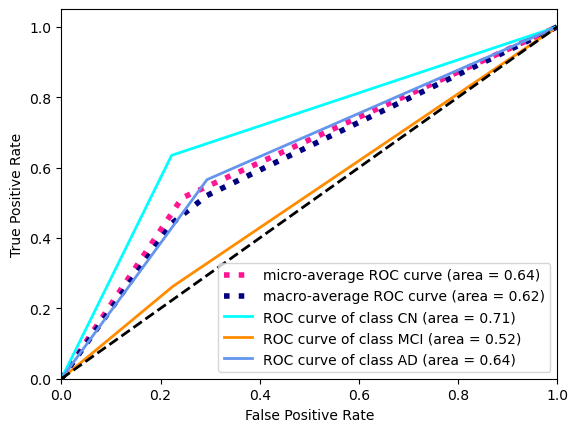

In [277]:
draw_ROC_curve(y,y_pred)

In [265]:
roc_auc = multiclass_roc_auc_score(y, y_pred)   
roc_auc

0.6203387574182221

In [280]:
y_pred = model_xgb.predict(X)    
report = classification_report(y, y_pred.round())  
print(report) 

              precision    recall  f1-score   support

           0       0.54      0.60      0.57       104
           1       0.32      0.24      0.27        80
           2       0.53      0.57      0.54       145

    accuracy                           0.50       329
   macro avg       0.46      0.47      0.46       329
weighted avg       0.48      0.50      0.49       329



In [281]:
#labels_out = np.argmax(y_pred, axis=1)
roc_auc = multiclass_roc_auc_score(y, y_pred)   
#roc_auc_list_testOrg3.append(roc_auc)  

/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/975491976.py:28: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])


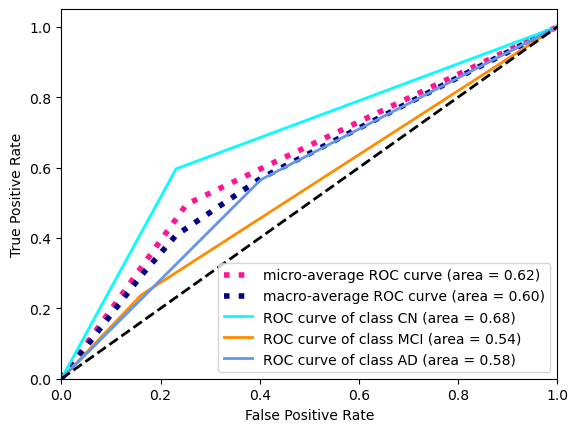

In [282]:
draw_ROC_curve(y,y_pred)

In [263]:
### Now determine 

0.6008739155162405

### Evaluate GSE63060 model measured with GSE63061 data

In [ ]:
['HS.543114', 'HS.538581', 'HS.576547', 'HS.570775', 'HS.495542', 'HS.149995', 'EIF4G1.3', 'MAP2.3', 'HS.210399', 'OR10AG1', 'RY1', 'HS.543040', 'HS.562189', 'HS.216701', 'HS.126491', 'CREG2', 'ASTN1.1', 'FMNL2.1', 'HS.297337', 'HS.574821', 'LOC554226.1']
df_genes_ncbi_GSE63061_df[['EIF4G1', 'MAP2','ASTN1', 'FMNL2']]

In [283]:
GSE63060_non_included_in_GSE63061 = ['HS.543114', 'HS.538581', 'HS.576547', 'HS.570775', 'HS.495542',
                                     'HS.149995', 'EIF4G1.3', 'MAP2.3', 'HS.210399', 'OR10AG1', 'RY1', 
                                     'HS.543040', 'HS.562189', 'HS.216701', 'HS.126491', 'CREG2', 'ASTN1.1',
                                     'FMNL2.1', 'HS.297337', 'HS.574821', 'LOC554226.1']
#result = list((set(a) ^ set(b)))
result_GSE63060 = list(set(GSE63060_essential_features).symmetric_difference(set(GSE63060_non_included_in_GSE63061)))

In [284]:
len(result_GSE63060)

48

In [287]:
result_GSE63060.extend(['EIF4G1', 'MAP2','ASTN1', 'FMNL2'])

In [288]:
len(result_GSE63060)

52

In [362]:
X = GSE63060_geneExpression_df[result_GSE63060]
y = GSE63060_geneExpression_df['status:ch1']

In [363]:
from sklearn.preprocessing import MinMaxScaler
t = MinMaxScaler()
t.fit(X)
X[:] = t.transform(X)
y = y.map({'CTL': 0,'MCI': 1,'AD': 2})
y.value_counts()

/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)
/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)


2    145
0    104
1     80
Name: status:ch1, dtype: int64

In [367]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size=0.30)

In [368]:
from sklearn.svm import SVC
model_svc=SVC()
model_svc.fit(X_train,Y_train)

SVC()

In [369]:
y_pred = model_svc.predict(X_test)    
report = classification_report(Y_test, y_pred.round())  
print(report) 

              precision    recall  f1-score   support

           0       0.93      0.69      0.79        39
           1       0.78      0.30      0.44        23
           2       0.54      0.89      0.67        37

    accuracy                           0.68        99
   macro avg       0.75      0.63      0.64        99
weighted avg       0.75      0.68      0.67        99



/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/975491976.py:28: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])


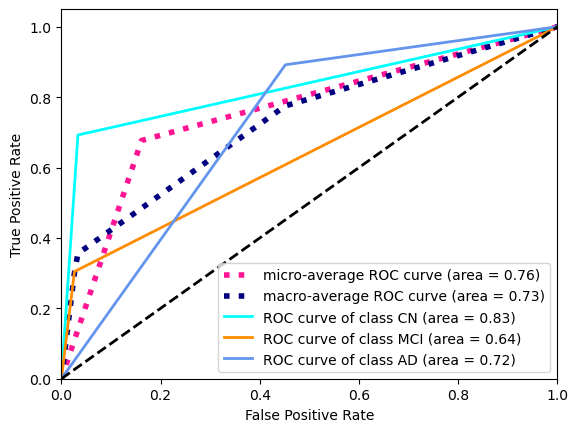

In [370]:
draw_ROC_curve(Y_test,y_pred)

In [371]:
X = ncbi_GSE63061_features_df[result_GSE63060]
y = ncbi_GSE63061_target_df

In [372]:
from sklearn.preprocessing import MinMaxScaler
t = MinMaxScaler()
t.fit(X)
X[:] = t.transform(X)
y = y.map({'CTL': 0,'MCI': 1,'AD': 2})
y.value_counts()

/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)
/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)


2    140
0    135
1    112
Name: status:ch1, dtype: int64

In [373]:
y_pred = model_svc.predict(X)    
report = classification_report(y, y_pred.round())  
print(report) 

              precision    recall  f1-score   support

           0       0.54      0.41      0.47       135
           1       0.35      0.12      0.18       112
           2       0.41      0.73      0.53       140

    accuracy                           0.44       387
   macro avg       0.44      0.42      0.39       387
weighted avg       0.44      0.44      0.41       387



/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/975491976.py:28: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])


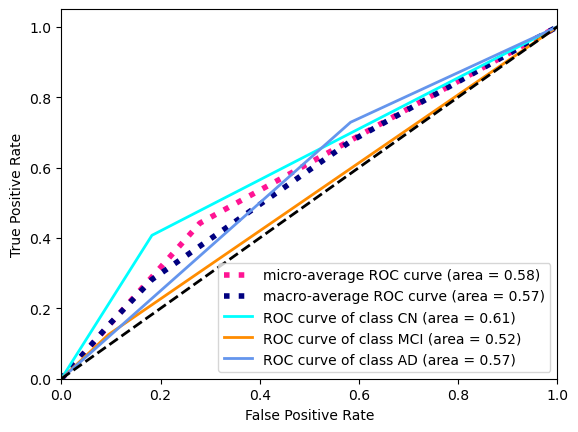

In [374]:
draw_ROC_curve(y,y_pred)

### Again check combined way for NCBI datasets

In [326]:
#add elements from result_GSE63060 and result_GSE63061 without common elements
# Converting the list into set
set1 = set(result_GSE63060)
set2 = set(result_GSE63061)
# find the union of the sets and converting resultant set to list
result_GSE63060_GSE63061 = list(set1.union(set2))

In [327]:
len(result_GSE63060_GSE63061)

125

In [331]:
GSE63060_GSE63061_geneExpression_df[result_GSE63060_GSE63061].head(1)

,HLA-A29.1,FBXL3.1,LOC646019,RCSD1,CD72,LOC652164,CTSS,SERF1A,CTAG1A.1,ABCA7.2,...,ING3.2,MAP2,LGALS14.1,HS.562367,POLR2C,DGKQ,KIR2DL5A.2,LOC727987,OR51S1,EZH1
0,7.423783,7.405443,7.476901,9.373785,8.097817,7.439393,10.150755,7.49833,7.427307,7.398271,...,8.073246,7.473612,7.565344,7.605295,9.095672,9.368669,7.421857,7.477966,7.469942,7.76604


In [332]:
GSE63060_GSE63061_geneExpression_df.shape

(716, 25278)

In [336]:
GSE63060_GSE63061_geneExpression_reset_df = GSE63060_GSE63061_geneExpression_df.copy()

In [344]:
GSE63060_GSE63061_geneExpression_reset_df.reset_index(drop=True, inplace = True)

In [375]:
X=GSE63060_GSE63061_geneExpression_reset_df[result_GSE63060_GSE63061]

In [376]:
GSE63060_GSE63061_geneExpression_reset_df.shape

(716, 25278)

In [377]:
y = GSE63060_GSE63061_geneExpression_reset_df['status:ch1']

In [378]:
from sklearn.preprocessing import MinMaxScaler
t = MinMaxScaler()
t.fit(X)
X[:] = t.transform(X)
y = y.map({'CTL': 0,'MCI': 1,'AD': 2})
y.value_counts()

/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)
/var/folders/bq/sdm0wvbs55vgz21fqdplwghm0000gn/T/ipykernel_2085/2076248721.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[:] = t.transform(X)


2    285
0    239
1    192
Name: status:ch1, dtype: int64

In [382]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size=0.15)

In [383]:
from sklearn.svm import SVC
model_svc=SVC()
model_svc.fit(X_train,Y_train)

SVC()

In [384]:
y_pred = model_svc.predict(X)    
report = classification_report(y, y_pred.round())  
print(report) 

              precision    recall  f1-score   support

           0       0.65      0.57      0.61       239
           1       0.00      0.00      0.00       192
           2       0.50      0.89      0.64       285

    accuracy                           0.55       716
   macro avg       0.38      0.49      0.42       716
weighted avg       0.42      0.55      0.46       716



/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/manashsarma/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
